# Time Series Exam Toolkit - V2
Run the cells sequentially. This notebook generates mock data, establishes your functions, and demonstrates Univariate and Multivariate forecasting with plots.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import pmdarima as pm
from prophet import Prophet

import warnings
warnings.filterwarnings('ignore')

/opt/anaconda3/envs/ML/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1. Data Generator & Preprocessing

In [2]:
def generate_mock_data():
    np.random.seed(42)
    dates = pd.date_range(start='2023-01-01', periods=120, freq='D')
    
    # Components
    trend = np.linspace(10, 50, 120)
    seasonality = 10 * np.sin(np.arange(120) * (2 * np.pi / 7)) # Weekly
    exog = np.random.normal(50, 15, 120) # e.g., ad spend
    exog_effect = exog * 0.3
    noise = np.random.normal(0, 5, 120)
    
    # Univariate Target (Trend + Seasonality + Noise)
    target_uni = trend + seasonality + noise
    
    # Multivariate Target (Trend + Seasonality + Exog + Noise)
    target_multi = trend + seasonality + exog_effect + noise
    
    df = pd.DataFrame({'date': dates, 'target_uni': target_uni, 'target_multi': target_multi, 'promo_spend': exog})
    
    train = df.iloc[:-14]
    test = df.iloc[-14:]
    
    return train, test

def prep_data(df, date_col='date', freq='D'):
    df_prep = df.copy()
    if date_col in df_prep.columns:
        df_prep[date_col] = pd.to_datetime(df_prep[date_col])
        df_prep = df_prep.set_index(date_col)
    df_prep = df_prep.asfreq(freq)
    df_prep = df_prep.ffill() # <--- FIXED: Modern Pandas ffill
    return df_prep

# Generate data for the demos
train_raw, test_raw = generate_mock_data()
train_df = prep_data(train_raw)
test_df = prep_data(test_raw)

### 2. Diagnostics & Plotting Helpers

In [3]:
def run_diagnostics(timeseries, seasonal_period=7):
    print('--- Dickey-Fuller Test ---')
    dftest = adfuller(timeseries.dropna(), autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Observations Used'])
    print(dfoutput)
    print("Stationary!" if dftest[1] <= 0.05 else "Non-stationary! Differencing needed.")
    print('\n')
    
    fig, ax = plt.subplots(3, 1, figsize=(10, 8))
    timeseries.plot(ax=ax[0], title='Time Series')
    plot_acf(timeseries.dropna(), ax=ax[1], lags=30)
    plot_pacf(timeseries.dropna(), ax=ax[2], lags=30)
    plt.tight_layout()
    plt.show()
    
    decomp = seasonal_decompose(timeseries.dropna(), period=seasonal_period, model='additive')
    decomp.plot()
    plt.show()

def plot_forecast(train, test, forecast, title="Forecast vs Actuals"):
    plt.figure(figsize=(12, 5))
    plt.plot(train.index, train, label='Train')
    plt.plot(test.index, test, label='Test (Actual)')
    plt.plot(test.index, forecast, label='Forecast', linestyle='--')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

def evaluate_forecast(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    print(f"RMSE: {rmse:.4f} | MAE: {mae:.4f} | MAPE: {mape:.4f}")
    return rmse

### 3. Model Functions

In [4]:
def run_holt_winters(train_series, steps, seasonal_periods=7):
    # Strictly univariate
    model = ExponentialSmoothing(train_series, trend='add', seasonal='add', seasonal_periods=seasonal_periods)
    fitted_model = model.fit()
    return fitted_model.forecast(steps)

def run_auto_arima(y_train, steps, X_train=None, X_test=None, m=7):
    model = pm.auto_arima(
        y_train, 
        X=X_train,
        seasonal=True, m=m,
        stepwise=True, suppress_warnings=True, error_action="ignore"
    )
    return model.predict(n_periods=steps, X=X_test)

def run_prophet(train_df, steps, target_col, exog_cols=None, test_exog_df=None):
    df_prophet = train_df.reset_index()[['date', target_col]].rename(columns={'date': 'ds', target_col: 'y'})
    m = Prophet(daily_seasonality=False, yearly_seasonality=False)
    
    if exog_cols:
        for col in exog_cols:
            df_prophet[col] = train_df[col].values
            m.add_regressor(col)
            
    m.fit(df_prophet)
    future = m.make_future_dataframe(periods=steps, freq='D')
    
    if exog_cols and test_exog_df is not None:
        # Combine train and test exog for the future dataframe
        exog_all = pd.concat([train_df[exog_cols], test_exog_df[exog_cols]])
        for col in exog_cols:
            future[col] = exog_all[col].values
            
    forecast = m.predict(future)
    return forecast.set_index('ds').iloc[-steps:]['yhat']

### 4. DEMO: Univariate Forecasting
Predicting `target_uni` using only past values.

========== UNIVARIATE DEMO ==========
--- Dickey-Fuller Test ---
Test Statistic       -0.572234
p-value               0.877133
#Lags Used            7.000000
Observations Used    98.000000
dtype: float64
Non-stationary! Differencing needed.




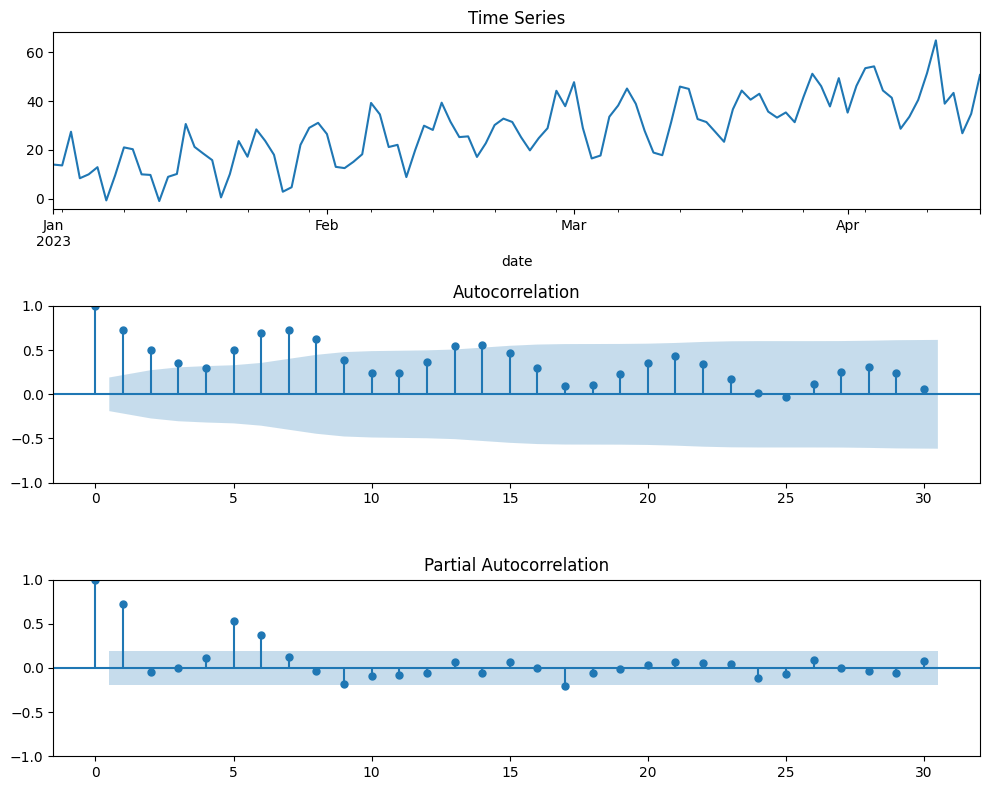

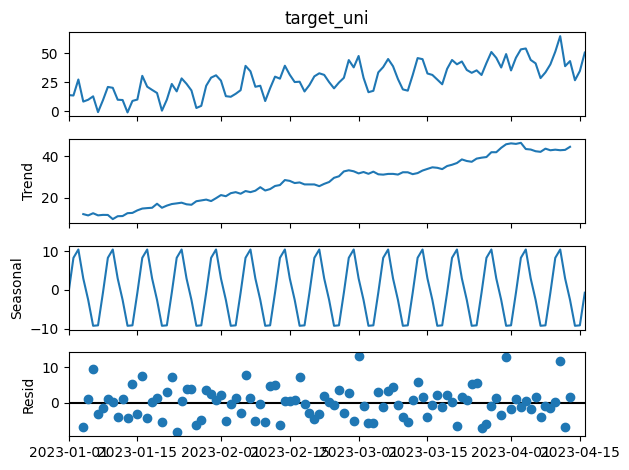


--- Holt-Winters (Univariate) ---
RMSE: 5.3344 | MAE: 4.0039 | MAPE: 0.0898


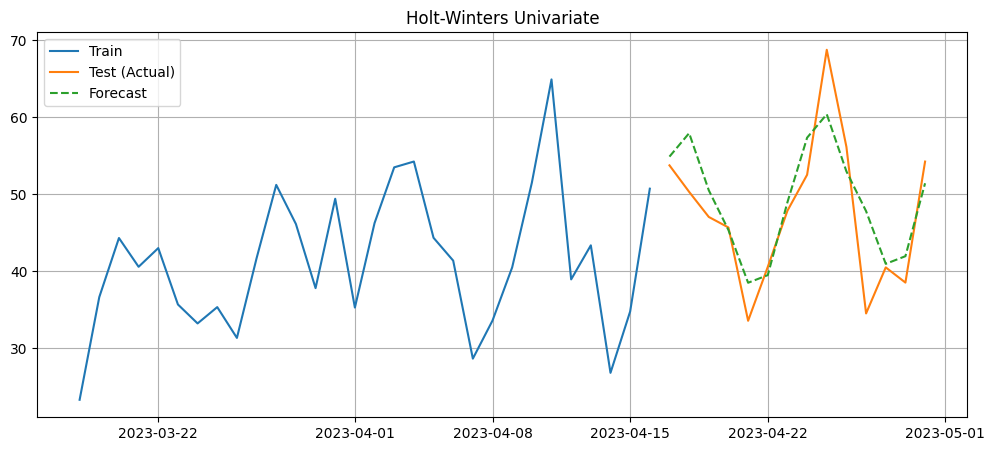


--- Auto-ARIMA (Univariate) ---
RMSE: 6.2772 | MAE: 4.7861 | MAPE: 0.1013


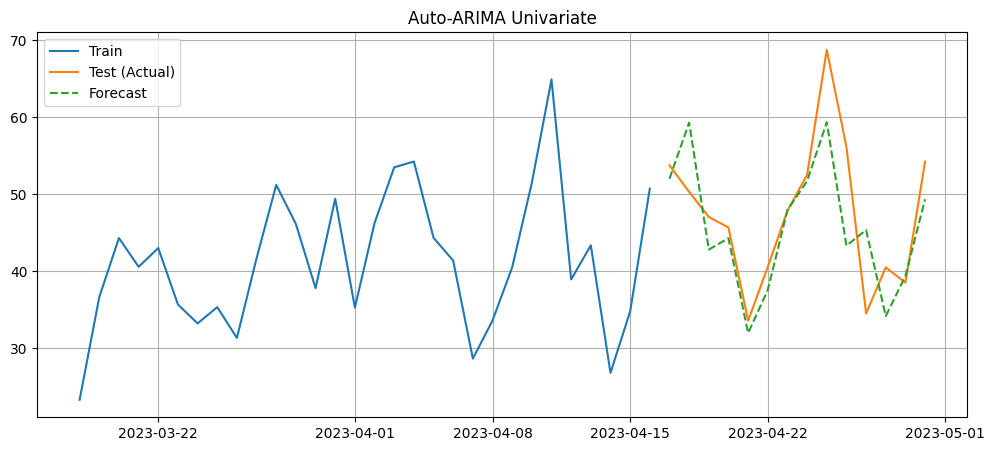

In [5]:
print("========== UNIVARIATE DEMO ==========")
y_train_uni = train_df['target_uni']
y_test_uni = test_df['target_uni']
steps = len(y_test_uni)

# 1. Diagnostics
run_diagnostics(y_train_uni)

# 2. Holt-Winters
print("\n--- Holt-Winters (Univariate) ---")
hw_preds = run_holt_winters(y_train_uni, steps)
evaluate_forecast(y_test_uni, hw_preds)
plot_forecast(y_train_uni[-30:], y_test_uni, hw_preds, "Holt-Winters Univariate")

# 3. Auto-ARIMA
print("\n--- Auto-ARIMA (Univariate) ---")
arima_uni_preds = run_auto_arima(y_train_uni, steps)
evaluate_forecast(y_test_uni, arima_uni_preds)
plot_forecast(y_train_uni[-30:], y_test_uni, arima_uni_preds, "Auto-ARIMA Univariate")

### 5. DEMO: Multivariate Forecasting
Predicting `target_multi` using past values AND the exogenous variable `promo_spend`.

========== MULTIVARIATE DEMO ==========

--- Auto-SARIMAX (Multivariate) ---
RMSE: 6.2619 | MAE: 4.8366 | MAPE: 0.0792


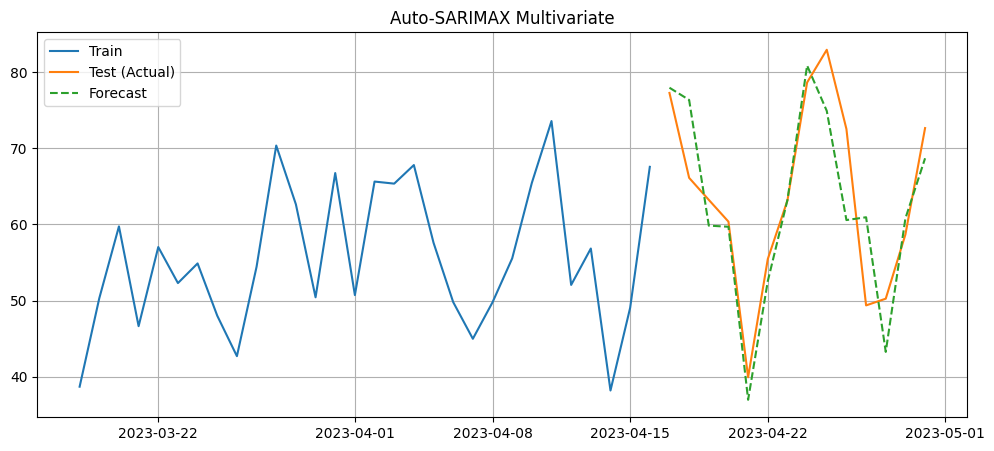

00:43:35 - cmdstanpy - INFO - Chain [1] start processing
00:43:35 - cmdstanpy - INFO - Chain [1] done processing



--- Prophet (Multivariate) ---
RMSE: 5.5913 | MAE: 4.2666 | MAPE: 0.0689


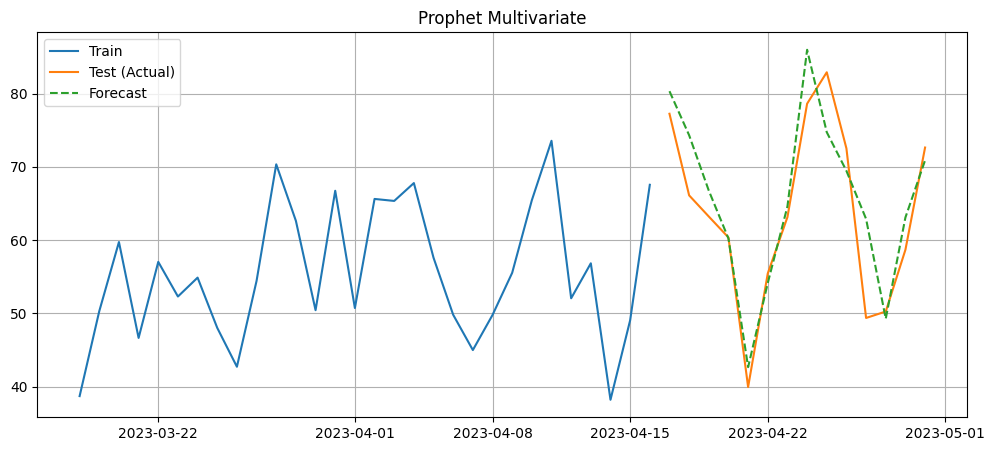

In [6]:
print("========== MULTIVARIATE DEMO ==========")
y_train_multi = train_df['target_multi']
y_test_multi = test_df['target_multi']

X_train = train_df[['promo_spend']]
X_test = test_df[['promo_spend']]

# 1. Auto-SARIMAX (Multivariate)
print("\n--- Auto-SARIMAX (Multivariate) ---")
arima_multi_preds = run_auto_arima(y_train_multi, steps, X_train=X_train, X_test=X_test)
evaluate_forecast(y_test_multi, arima_multi_preds)
plot_forecast(y_train_multi[-30:], y_test_multi, arima_multi_preds, "Auto-SARIMAX Multivariate")

# 2. Prophet (Multivariate)
print("\n--- Prophet (Multivariate) ---")
prophet_multi_preds = run_prophet(train_df, steps, target_col='target_multi', 
                                  exog_cols=['promo_spend'], test_exog_df=test_df)
evaluate_forecast(y_test_multi, prophet_multi_preds)
plot_forecast(y_train_multi[-30:], y_test_multi, prophet_multi_preds, "Prophet Multivariate")

--- Results for ADDITIVE_DATA ---
Mean/Std Correlation: 0.015
Recommended Seasonality: ADDITIVE



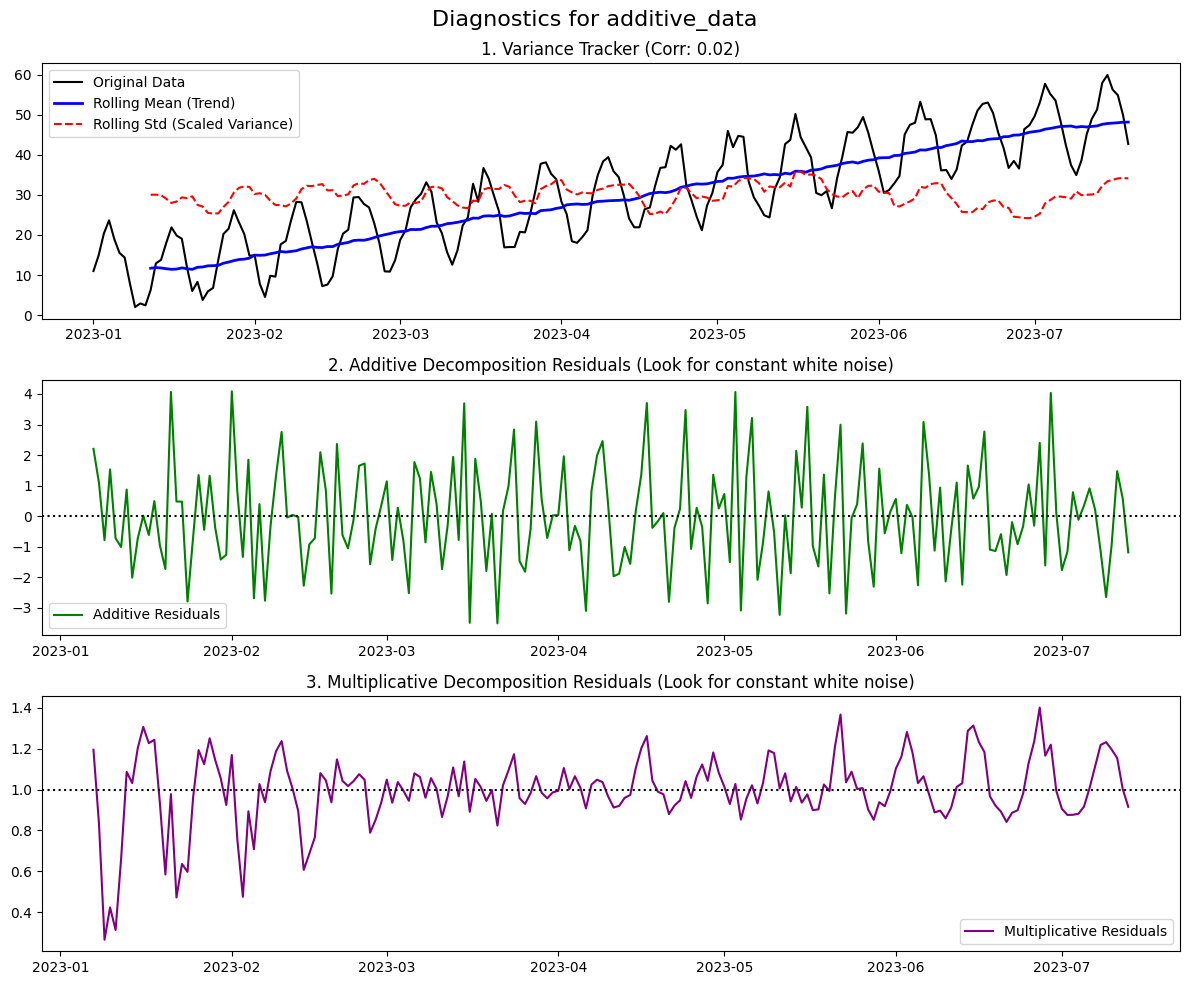

--- Results for MULTIPLICATIVE_DATA ---
Mean/Std Correlation: 0.974
Recommended Seasonality: MULTIPLICATIVE



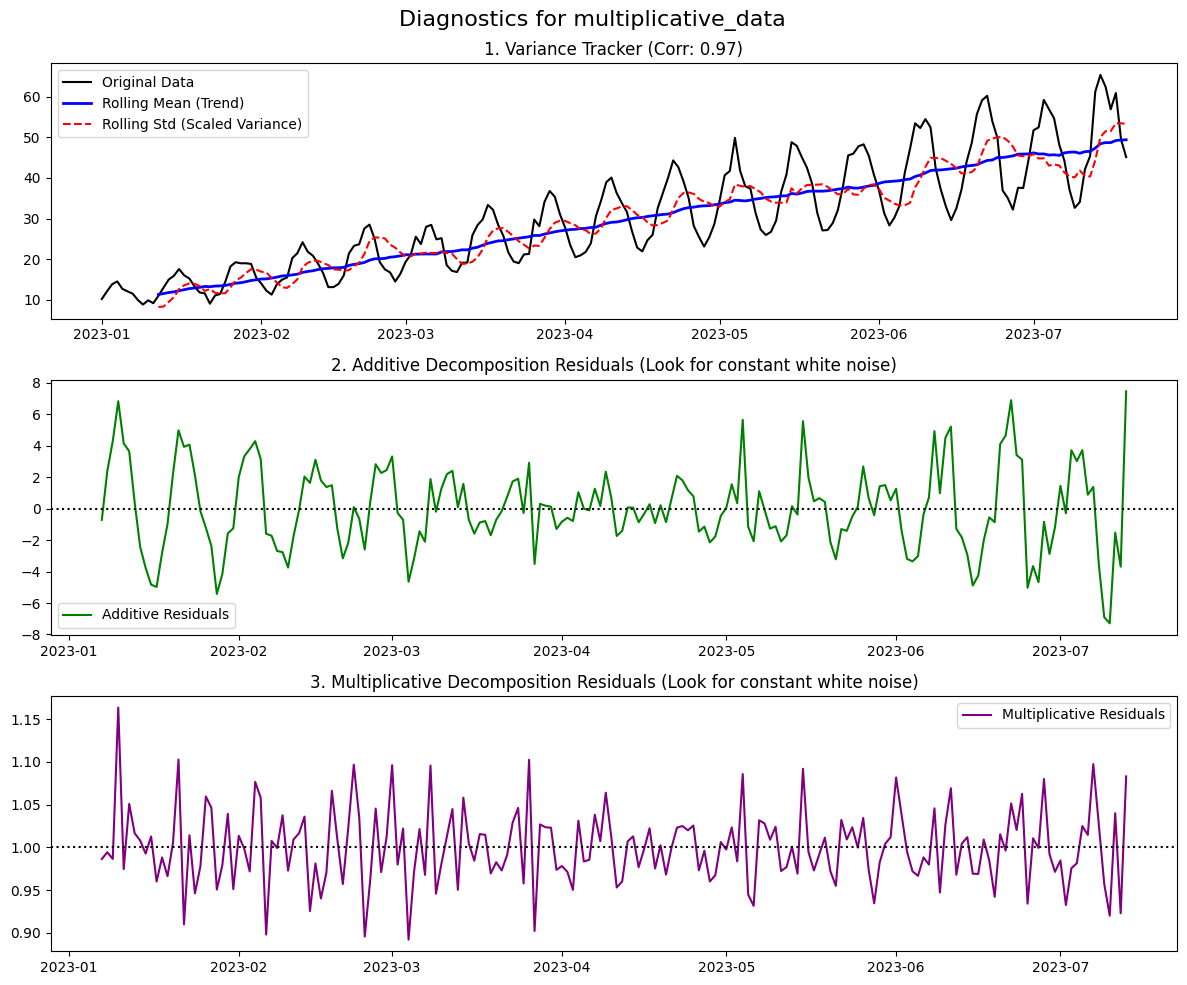

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

def generate_seasonality_test_data():
    """Generates one explicitly Additive and one explicitly Multiplicative dataset."""
    np.random.seed(42)
    time = np.arange(200)
    
    # Base components
    trend = np.linspace(10, 50, 200)
    seasonal_wave = np.sin(time * (2 * np.pi / 12))
    
    # 1. Additive: constant variance regardless of trend
    noise_add = np.random.normal(0, 2, 200)
    y_add = trend + (10 * seasonal_wave) + noise_add
    
    # 2. Multiplicative: variance grows as trend grows
    noise_mult = np.random.normal(1, 0.05, 200)
    y_mult = trend * (1 + 0.3 * seasonal_wave) * noise_mult
    
    df = pd.DataFrame({
        'date': pd.date_range('2023-01-01', periods=200, freq='D'),
        'additive_data': y_add,
        'multiplicative_data': y_mult
    }).set_index('date')
    
    return df

def detect_and_plot_seasonality(series, period=12, window=12):
    """
    Checks if a series is additive or multiplicative based on the correlation 
    between its rolling mean and rolling standard deviation, and plots the results.
    """
    # 1. Calculate rolling metrics
    roll_mean = series.rolling(window=window).mean().dropna()
    roll_std = series.rolling(window=window).std().dropna()
    
    # 2. The Metric: Correlation between level and variance
    correlation = np.corrcoef(roll_mean, roll_std)[0, 1]
    
    # 3. Decision Logic (0.3 is a standard heuristic threshold)
    seasonality_type = 'multiplicative' if correlation > 0.3 else 'additive'
    
    print(f"--- Results for {series.name.upper()} ---")
    print(f"Mean/Std Correlation: {correlation:.3f}")
    print(f"Recommended Seasonality: {seasonality_type.upper()}\n")

    # --- PLOTTING ---
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    fig.suptitle(f"Diagnostics for {series.name}", fontsize=16)

    # Plot 1: Raw Data & Rolling Metrics
    axes[0].plot(series.index, series, label='Original Data', color='black')
    axes[0].plot(roll_mean.index, roll_mean, label='Rolling Mean (Trend)', color='blue', linewidth=2)
    # Scaling the std purely so it's visible on the same y-axis scale
    axes[0].plot(roll_std.index, roll_std * (series.mean() / roll_std.mean()), 
                 label='Rolling Std (Scaled Variance)', color='red', linestyle='--')
    axes[0].set_title(f"1. Variance Tracker (Corr: {correlation:.2f})")
    axes[0].legend()

    # Plot 2: Additive Residuals
    decomp_add = seasonal_decompose(series, model='additive', period=period)
    axes[1].plot(series.index, decomp_add.resid, label='Additive Residuals', color='green')
    axes[1].axhline(0, color='black', linestyle=':')
    axes[1].set_title("2. Additive Decomposition Residuals (Look for constant white noise)")
    axes[1].legend()

    # Plot 3: Multiplicative Residuals
    # Safe handling in case of non-positive values which break multiplicative decomp
    safe_series = series.copy()
    if (safe_series <= 0).any():
        safe_series = safe_series - safe_series.min() + 1 
        
    decomp_mult = seasonal_decompose(safe_series, model='multiplicative', period=period)
    axes[2].plot(series.index, decomp_mult.resid, label='Multiplicative Residuals', color='purple')
    axes[2].axhline(1, color='black', linestyle=':')
    axes[2].set_title("3. Multiplicative Decomposition Residuals (Look for constant white noise)")
    axes[2].legend()

    plt.tight_layout()
    plt.show()
    
    return seasonality_type

# ==========================================
# EXECUTION DEMO
# ==========================================
df_test = generate_seasonality_test_data()

# Test 1: Should output Additive
ans_add = detect_and_plot_seasonality(df_test['additive_data'], period=12)

# Test 2: Should output Multiplicative
ans_mult = detect_and_plot_seasonality(df_test['multiplicative_data'], period=12)

Testing Dynamic HW on Additive Data:
--- Dynamically Tuning Holt-Winters ---
--- Results for ADDITIVE_DATA ---
Mean/Std Correlation: 0.015
Recommended Seasonality: ADDITIVE



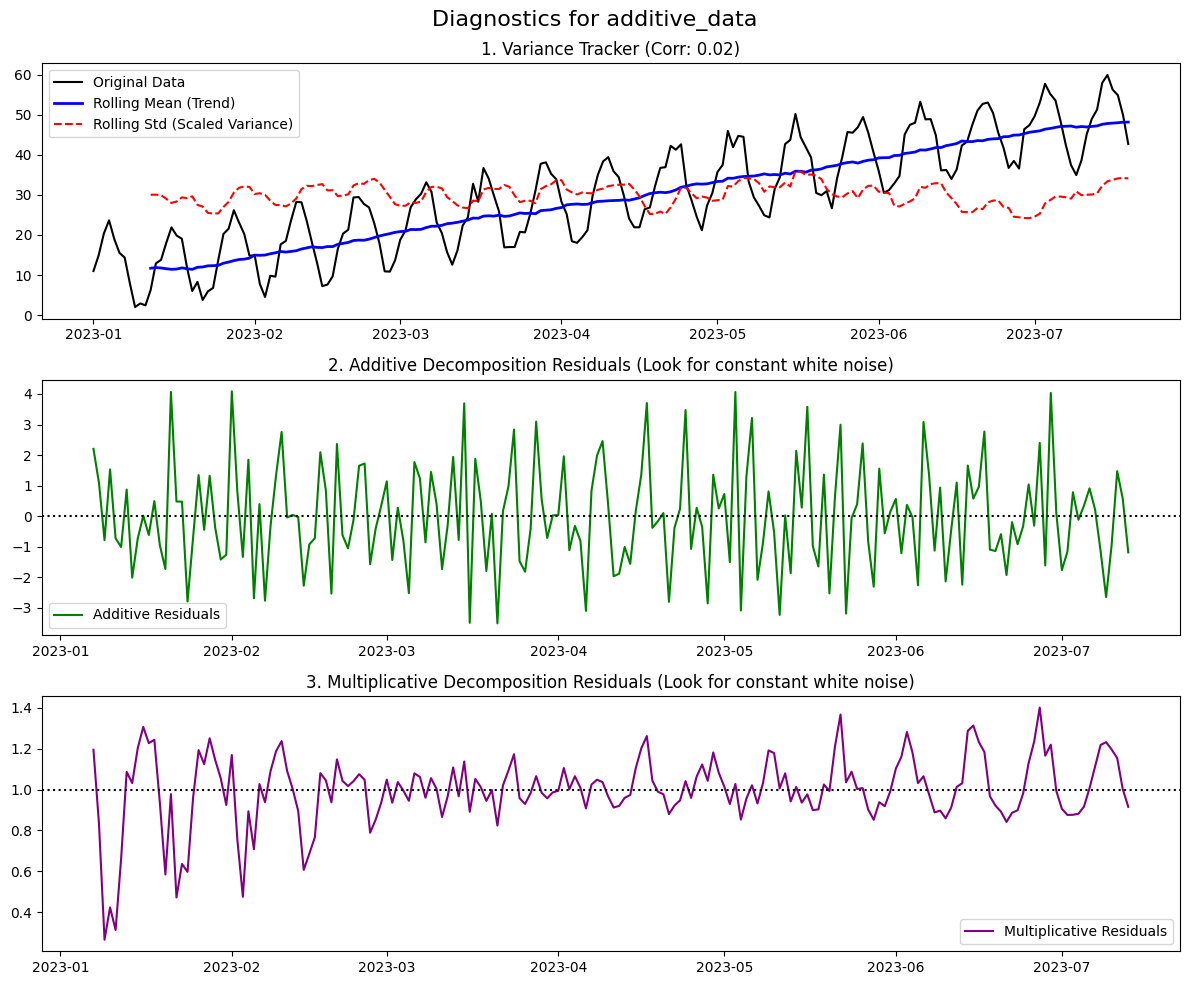

Applying ExponentialSmoothing with trend='add' and seasonal='add'

Testing Dynamic HW on Multiplicative Data:
--- Dynamically Tuning Holt-Winters ---
--- Results for MULTIPLICATIVE_DATA ---
Mean/Std Correlation: 0.974
Recommended Seasonality: MULTIPLICATIVE



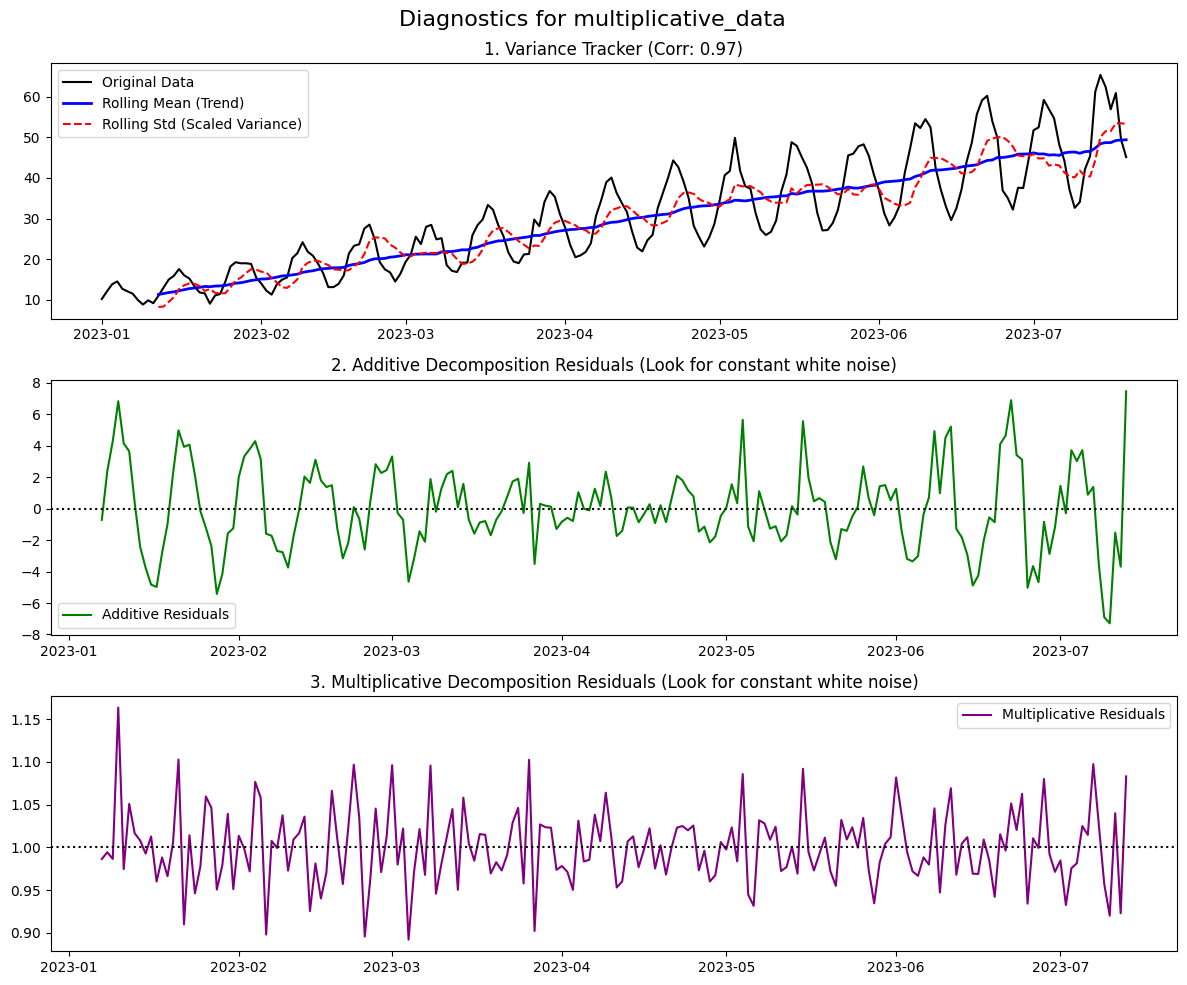

Applying ExponentialSmoothing with trend='add' and seasonal='mul'


In [8]:
def run_dynamic_holt_winters(train_series, steps, seasonal_periods=7):
    """
    Automatically detects seasonality type, plots diagnostics, and runs 
    the appropriate Holt-Winters model with a safety shift for non-positive data.
    """
    print(f"--- Dynamically Tuning Holt-Winters ---")
    
    # 1. Detect Seasonality Type (calls our previously defined function)
    # We pass the seasonal_periods as both the period and the window
    detected_type = detect_and_plot_seasonality(
        train_series, 
        period=seasonal_periods, 
        window=seasonal_periods
    )
    
    # Map output to statsmodels accepted parameters
    hw_seasonal = 'mul' if detected_type == 'multiplicative' else 'add'
    hw_trend = 'add' # Defaulting trend to 'add' is generally the safest baseline
    
    print(f"Applying ExponentialSmoothing with trend='{hw_trend}' and seasonal='{hw_seasonal}'")
    
    # 2. Safety Check for Multiplicative Model
    series_to_fit = train_series.copy()
    offset = 0
    
    if hw_seasonal == 'mul' and (series_to_fit <= 0).any():
        print("⚠️ Warning: Multiplicative model requires strictly positive data.")
        print("Temporarily shifting data up to prevent statsmodels from crashing...")
        # Shift everything so the minimum value becomes 1
        offset = abs(series_to_fit.min()) + 1
        series_to_fit = series_to_fit + offset
        
    # 3. Fit and Forecast
    model = ExponentialSmoothing(
        series_to_fit, 
        trend=hw_trend, 
        seasonal=hw_seasonal, 
        seasonal_periods=seasonal_periods
    )
    fitted_model = model.fit()
    forecast = fitted_model.forecast(steps)
    
    # 4. Reverse the shift to return predictions to their original scale
    if offset > 0:
        print("Reversing the data shift for final predictions.")
        forecast = forecast - offset
        
    return forecast

# ==========================================
# EXECUTION DEMO
# ==========================================
# Assuming 'df_test' from the previous snippet is already loaded in your notebook

print("Testing Dynamic HW on Additive Data:")
add_forecast = run_dynamic_holt_winters(df_test['additive_data'], steps=14, seasonal_periods=12)

print("\nTesting Dynamic HW on Multiplicative Data:")
mult_forecast = run_dynamic_holt_winters(df_test['multiplicative_data'], steps=14, seasonal_periods=12)